In [1]:
import pandas as pd
from os import scandir
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import pickle
# custom
import cvTools.cv_interaction as cst

# Thresholding - HSV

## Playing with parameters

In [11]:
with open('thresh_HSV.pickle', 'rb') as fin: thresh = pickle.load(fin)

### bad example

In [17]:
low = (0, 110, 50)
high = (23, 255, 210)
low, high, thresh = cst.threshing('data/NV/ISIC_0000039_downsampled.jpg', 'HSV', thresh=thresh, low=low, high=high)

In [9]:
low, high, thresh = cst.threshing('data/NV/ISIC_0000039_downsampled.jpg', 'HSV', thresh=thresh, low=low, high=high)

### Good example

In [16]:
low = (0, 110, 50)
high = (23, 255, 210)
low, high, thresh = cst.threshing('data/NV/ISIC_0008236_downsampled.jpg', 'HSV', thresh=thresh, low=low, high=high)

In [ ]:
low, high, thresh = cst.threshing('data/NV/ISIC_0000039_downsampled.jpg', 'HSV', thresh=thresh, low=low, high=high)

---

In [8]:
with open('thresh_HSV.pickle', 'wb') as fout: pickle.dump(thresh, fout, protocol=-1)

## Application

In [ ]:
img_path = 'data/MEL/ISIC_0014862_downsampled.jpg'
img = cv.imread(img_path)
img = cv.cvtColor(img, cv.COLOR_BGR2HSV)
mask = cv.inRange(img, (0, 110, 50), (23, 255, 210))
img = cv.bitwise_and(img, img, mask=mask)
img = cv.cvtColor(img, cv.COLOR_HSV2BGR)

# Thresholding - LAB

In [8]:
with open('thresh_LAB.pickle', 'rb') as fin: thresh = pickle.load(fin)

In [12]:
low, high, thresh = cst.threshing('data/MEL/ISIC_0014366_downsampled.jpg', 'LAB', thresh=thresh, low=low, high=high)

# KMeans

In [27]:
img = cv.imread('data/NV/ISIC_0007796_downsampled.jpg')
show(img)
Z = img.reshape((-1, 3)).astype(np.float32)
img = cv.cvtColor(cv.imread('data/NV/ISIC_0007796_downsampled.jpg'), cv.COLOR_BGR2HSV)
prova = cv.inRange(img, (0, 100, 16), (17, 255, 200))

# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 2
_, label, center = cv.kmeans(Z,K,None,criteria,10, cv.KMEANS_PP_CENTERS)
 
# Now convert back into uint8, and make original image
center = np.uint8(center)

# darker region
arg_dark = np.argmin(center[..., 0])
flat_idx = np.nonzero(label.flatten() == arg_dark)

# mask for image
mask = np.zeros(img.shape[0] * img.shape[1], dtype=np.uint8)
mask[flat_idx] = 255
mask = mask.reshape(img.shape[:2])

masked_img = cv.bitwise_and(img, img, mask=mask)

# bilateral filter
bil = cv.bilateralFilter(masked_img, d=9, sigmaColor=10, sigmaSpace=39)
# masked_img = cv.cvtColor(masked_img, cv.COLOR_BGR2GRAY)
masked_img = cv.cvtColor(masked_img, cv.COLOR_BGR2LAB)
bil = cv.cvtColor(bil, cv.COLOR_BGR2LAB)
# create a CLAHE object (Arguments are optional).
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(masked_img[..., 0])
cl2 = clahe.apply(bil[..., 0])
bil[..., 0] = cl2
masked_img[..., 0] = cl1

# out = np.hstack((masked_img, cl1))
# show(out)
show(cv.cvtColor(masked_img, cv.COLOR_LAB2BGR))
show(cv.cvtColor(bil, cv.COLOR_LAB2BGR))

## ?

In [28]:
img = cv.imread('data/NV/ISIC_0007796_downsampled.jpg')
show(img)
Z = img.reshape((-1, 3)).astype(np.float32)

# define criteria, number of clusters(K) and apply kmeans()
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 2
_, label, center = cv.kmeans(Z,K,None,criteria,10, cv.KMEANS_PP_CENTERS)
 
# Now convert back into uint8, and make original image
center = np.uint8(center)

# darker region
arg_dark = np.argmin(center[..., 0])
flat_idx = np.nonzero(label.flatten() == arg_dark)

# mask for image
mask = np.zeros(img.shape[0] * img.shape[1], dtype=np.uint8)
mask[flat_idx] = 255
mask = mask.reshape(img.shape[:2])

masked_img = cv.bitwise_and(img, img, mask=mask)

# bilateral filter
bil = cv.bilateralFilter(masked_img, d=9, sigmaColor=10, sigmaSpace=39)
# masked_img = cv.cvtColor(masked_img, cv.COLOR_BGR2GRAY)
masked_img = cv.cvtColor(masked_img, cv.COLOR_BGR2LAB)
bil = cv.cvtColor(bil, cv.COLOR_BGR2LAB)
# create a CLAHE object (Arguments are optional).
clahe = cv.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
cl1 = clahe.apply(masked_img[..., 0])
cl2 = clahe.apply(bil[..., 0])
bil[..., 0] = cl2
masked_img[..., 0] = cl1

# out = np.hstack((masked_img, cl1))
# show(out)
show(cv.cvtColor(masked_img, cv.COLOR_LAB2BGR))
show(cv.cvtColor(bil, cv.COLOR_LAB2BGR))

In [27]:
show(masked_img)

In [37]:
bil = cv.bilateralFilter(masked_img, d=9, sigmaColor=10, sigmaSpace=39)
show(np.hstack((masked_img, bil)))

# Matplotlib hsv

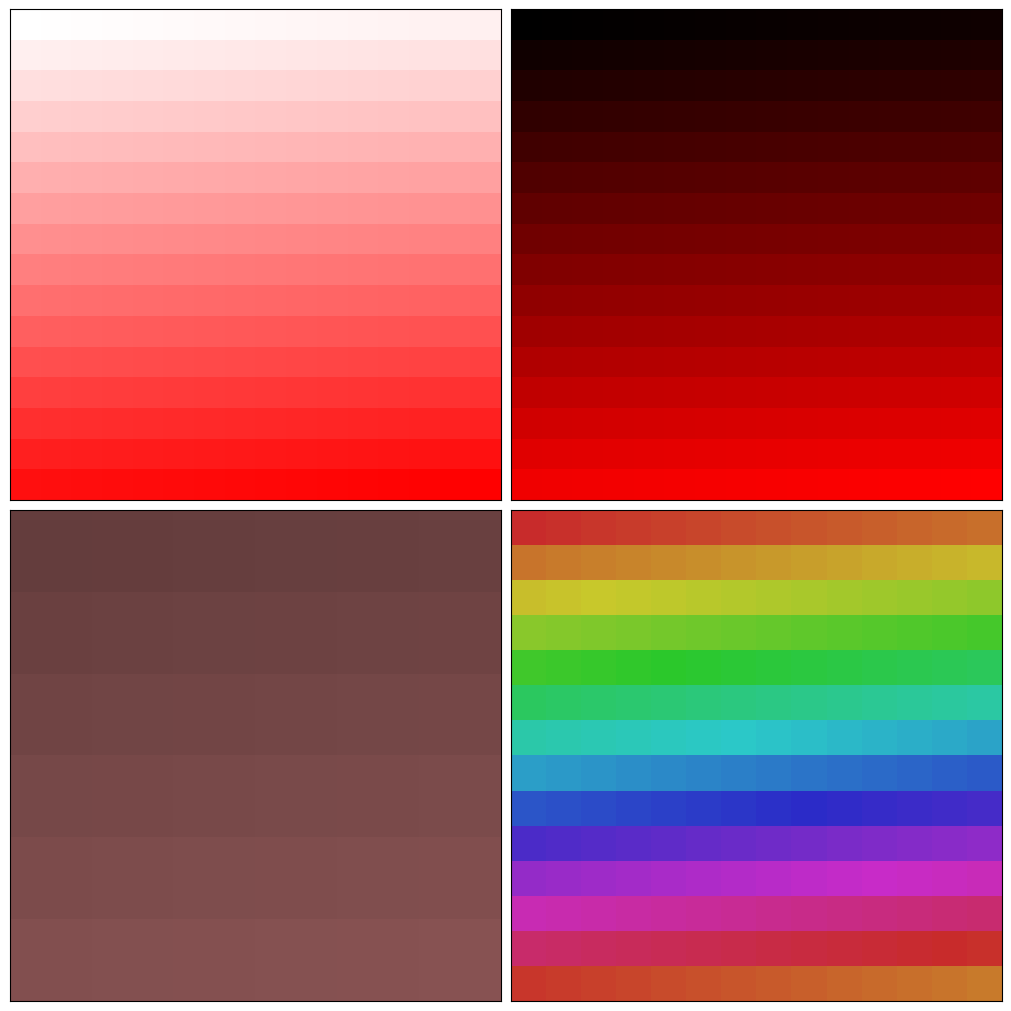

In [10]:
h = 180
img_sat = np.empty((16, 16, 3), dtype=np.uint8)
img_sat[..., 0] = h
img_sat[..., 1] = np.arange(256).reshape(16, 16)
img_sat[..., 2] = 255
img_sat = cv.cvtColor(img_sat, cv.COLOR_HSV2RGB)

img_val = np.empty((16, 16, 3), dtype=np.uint8)
img_val[..., 0] = h
img_val[..., 1] = 255
img_val[..., 2] = np.arange(256).reshape(16, 16)
img_val = cv.cvtColor(img_val, cv.COLOR_HSV2RGB)

cus = 100
img_cus = np.empty((6, 6, 3), dtype=np.uint8)
img_cus[..., 0] = h
img_cus[..., 1] = cus
img_cus[..., 2] = np.arange(cus, cus + 36).reshape(6, 6)
# img_cus[..., 2] = np.arange(cus, cus + 36).reshape(6, 6)
img_cus = cv.cvtColor(img_cus, cv.COLOR_HSV2RGB)

img_h = np.empty((14, 14, 3), dtype=np.uint8)
img_h[..., 0] = np.arange(196).reshape(14, 14)
img_h[..., 1] = 200
img_h[..., 2] = 200
img_h = cv.cvtColor(img_h, cv.COLOR_HSV2RGB)


fig, (axu, axd) = plt.subplots(2,2, figsize=(10, 10), layout='constrained')
axu[0].imshow(img_sat)
axu[1].imshow(img_val)
axd[0].imshow(img_cus)
axd[1].imshow(img_h)
for ax in np.concat((axu, axd)):
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()